
# DAPPC - LAB 2
## Identification of Homogeneous Groups of Patients with SOMs

In this notebook you will:

1. Load a prepared dataset  
2. Select the variables used for clustering  
3. Normalize the input features  
4. Define and train a square Self-Organizing Map (SOM)  
5. Extract the weight matrix of the trained SOM  
6. Apply hierarchical clustering on neuron weights  
7. Visualize the dendrogram and define the number of clusters  
8. Build the sample hits map and identify contiguous neuron bubbles  
9. Assign each subject to a winner neuron, a neuron cluster, and a bubble  
10. Save the results

We assume:
- The dataset is already prepared and filled (it has no MVs)
- Each row corresponds to one subject
- Subject identifiers are available in the first six columns of the dataset


## 0) Setup


In [179]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from matplotlib.patches import RegularPolygon
from matplotlib import cm, colors

from collections import deque
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from minisom import MiniSom


## 1) Load Dataset


In [180]:
file_path = 'Dataset_DAPPC_2026.xlsx'
sheet_name = 'Dataset_v1'

df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Initial shape:", df.shape)
df.head()


Initial shape: (3893, 76)


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,gender,age,weight,charlson_comorbidity_index,...,first_plateau_pressure,std_plateau_pressure,vent_duration_hours,outcome,comorb_total,comorb_catcardiac_cardiovascular,comorb_catrespiratory_pulmonary,comorb_catmetabolic_endocrine_renal,comorb_catneurological_neuromuscular_psychiatric,comorb_catsystemic_immune_oncologic
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,1,66,113.3,3,...,19.0,1.909727,96.0,2,1,0,0,1,0,0
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,1,53,106.7,5,...,10.0,8.337289,230.0,1,5,0,1,1,0,0
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,0,66,46.1,6,...,17.0,1.224745,34.0,1,4,0,0,1,0,0
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,1,49,106.0,1,...,11.0,4.877563,399.0,2,4,1,0,1,1,0
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,0,77,49.3,7,...,17.0,3.239768,155.0,2,4,1,0,1,0,1


## 2) Column Index Table


In [181]:
display(pd.DataFrame({
    "index": np.arange(df.shape[1]),
    "column_name": df.columns,
    "dtype": df.dtypes
}))


,index,column_name,dtype
subject_id,0,subject_id,int64
hadm_id,1,hadm_id,int64
stay_id,2,stay_id,int64
ICU,3,ICU,int64
ICU_intime,4,ICU_intime,str
...,...,...,...
comorb_catcardiac_cardiovascular,71,comorb_catcardiac_cardiovascular,int64
comorb_catrespiratory_pulmonary,72,comorb_catrespiratory_pulmonary,int64
comorb_catmetabolic_endocrine_renal,73,comorb_catmetabolic_endocrine_renal,int64
comorb_catneurological_neuromuscular_psychiatric,74,comorb_catneurological_neuromuscular_psychiatric,int64



## 3) Select Variables for SOM

Define here the variables that will be used to build the SOM.

You can specify them either:
- by column indices, or  
- by explicit column names.

Remember that we're going to use a clustering method (unsupervised learning approach).

In [182]:
# ============================================================
# 1. Define variable groups (data-driven, not necessarily contiguous)
#    Strategy: impute -> scale -> drop near-constant -> drop highly-correlated -> PCA loadings rank -> pick top-N original features
# ============================================================
TOP_N_FEATURES = 10
CORR_THRESHOLD = 0.90
PCA_COMPONENTS = 10  # use first K PCs to compute feature importance
VAR_THRESHOLD = 1e-6

# Restrict candidates to columns 10..54 (by index), regardless of contiguity elsewhere
candidate_cols = df.columns[10:54].tolist()  # 10..54 inclusive

outcome_col = 'outcome'

candidate_df = df[candidate_cols]
numeric_cols = candidate_df.select_dtypes(include=[np.number]).columns.tolist()

# Impute missing values (median) to make PCA/scaling work
X_cand = candidate_df[numeric_cols]
X_cand_imp = SimpleImputer(strategy='median').fit_transform(X_cand)

# Standardize (PCA/correlation/variance depend on scale)
X_z = StandardScaler().fit_transform(X_cand_imp)

# 1) Remove near-constant features
vt = VarianceThreshold(threshold=VAR_THRESHOLD)
X_vt = vt.fit_transform(X_z)
cols_vt = list(np.array(numeric_cols)[vt.get_support()])

# 2) Remove redundancy (high absolute correlation). Keep earlier columns when a pair is too correlated.
if X_vt.shape[1] > 1:
    corr = np.corrcoef(X_vt, rowvar=False)
    to_drop = set()
    for i in range(corr.shape[0]):
        if i in to_drop:
            continue
        for j in range(i + 1, corr.shape[1]):
            if j in to_drop:
                continue
            if abs(corr[i, j]) >= CORR_THRESHOLD:
                to_drop.add(j)

    keep_idx = [i for i in range(X_vt.shape[1]) if i not in to_drop]
    X_uncorr = X_vt[:, keep_idx]
    cols_uncorr = [cols_vt[i] for i in keep_idx]
else:
    X_uncorr = X_vt
    cols_uncorr = cols_vt

# 3) PCA-guided ranking of original features (still using original columns downstream)
if X_uncorr.shape[1] == 0:
    raise ValueError("No numeric features left after variance/correlation filtering.")

k = min(PCA_COMPONENTS, X_uncorr.shape[1])
pca = PCA(n_components=k, random_state=0)
pca.fit(X_uncorr)

# Feature importance: sum of squared loadings across PCs, weighted by explained variance ratio
importance = (pca.components_.T ** 2) @ pca.explained_variance_ratio_

rank_idx = np.argsort(-importance)
selected_cols = [cols_uncorr[i] for i in rank_idx[: min(TOP_N_FEATURES, len(rank_idx))]]

input_features = selected_cols
X = df[input_features].copy()
X = X.fillna(X.median(numeric_only=True))

print("Number of selected variables:", len(input_features))
print("First selected variable:", input_features[0])
print("Last selected variable:", input_features[-1])
print("Selected variables:", input_features)


Number of selected variables: 10
First selected variable: first_chloride
Last selected variable: first_systolic_blood_pressure
Selected variables: [np.str_('first_chloride'), np.str_('sedatives'), np.str_('opioids'), np.str_('first_sodium'), np.str_('std_creatinine'), np.str_('std_pO2'), np.str_('first_creatinine'), np.str_('first_pO2'), np.str_('std_sodium'), np.str_('first_systolic_blood_pressure')]



## 4) Normalize the Input Features

Since SOM training is distance-based, the variables must be on a comparable scale. Here we use min-max scaling.


In [183]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)



## 6) Define and Train the SOM

Main steps:
1. Define the dimension of the square SOM  
2. Create the SOM architecture  
3. Initialize the neuron weights  
4. Train the SOM


In [184]:
# ============================================================
# 1. Define the dimensions of the SOM (square SOM)
# ============================================================
n = 14 # Primo: 10x10, poi 12x12, poi 14x14

# ============================================================
# 2. Create the SOM architecture
# ============================================================
som = MiniSom(
    x=n,
    y=n,
    input_len=X_norm.shape[1],
    sigma=4,
    learning_rate=0.3,
    activation_distance='euclidean',
    topology='hexagonal',
    neighborhood_function='gaussian',
)

# ============================================================
# 3. Initialize and train the SOM
# ============================================================
som.random_weights_init(X_norm)
som.train(X_norm, num_iteration=200, use_epochs=True) #it may take a while (usually around 5-10 minutes)

print(f"Trained SOM: {n} x {n}")

Trained SOM: 14 x 14



## 7) Save the Trained SOM

The trained SOM can be saved and reused later without retraining.


In [185]:
 # adjust the filename and the directory in which you want to save the SOMs
som_filename = f"SOM_Dim_{n}x{n}.pkl"

with open(som_filename, 'wb') as f:
    pickle.dump(som, f)

print("Saved SOM to:", som_filename)


Saved SOM to: SOM_Dim_14x14.pkl



## 8) Extract the Weight Matrix

Each neuron of the trained SOM is associated with one weight vector.

We extract the neuron weights and reshape them into a 2D matrix:
- one row per neuron  
- one column per feature


In [186]:
# Check that the wight shapes are (number of neurons, number of features)
weights_3d = som.get_weights()         
weights = weights_3d.reshape(n * n, X.shape[1])
print("Weight matrix shape:", weights.shape)


Weight matrix shape: (196, 10)


In [187]:
# Stampa i pesi del nodo (0, 0)
weights_3d = som.get_weights()

print(weights_3d[0, 0, :])


[-1.30201856  0.32480519  0.19676482 -1.82184194  0.04161411  0.43055385
 -0.20403944 -0.0985607   2.03438013 -0.29266447]



## 9) Hierarchical Clustering on SOM Weights

We now apply agglomerative hierarchical clustering to the neuron weights.

As in the previous laboratory, we use:
- complete linkage  
- cityblock distance

Yuo're appling hierarchical clustering on SOM's neurons so the numbers on the x-axis represent the position of each neuron in the 2D Network -> the first (neuron number 0) is the top-left corner, the last one is the right-bottom corner.

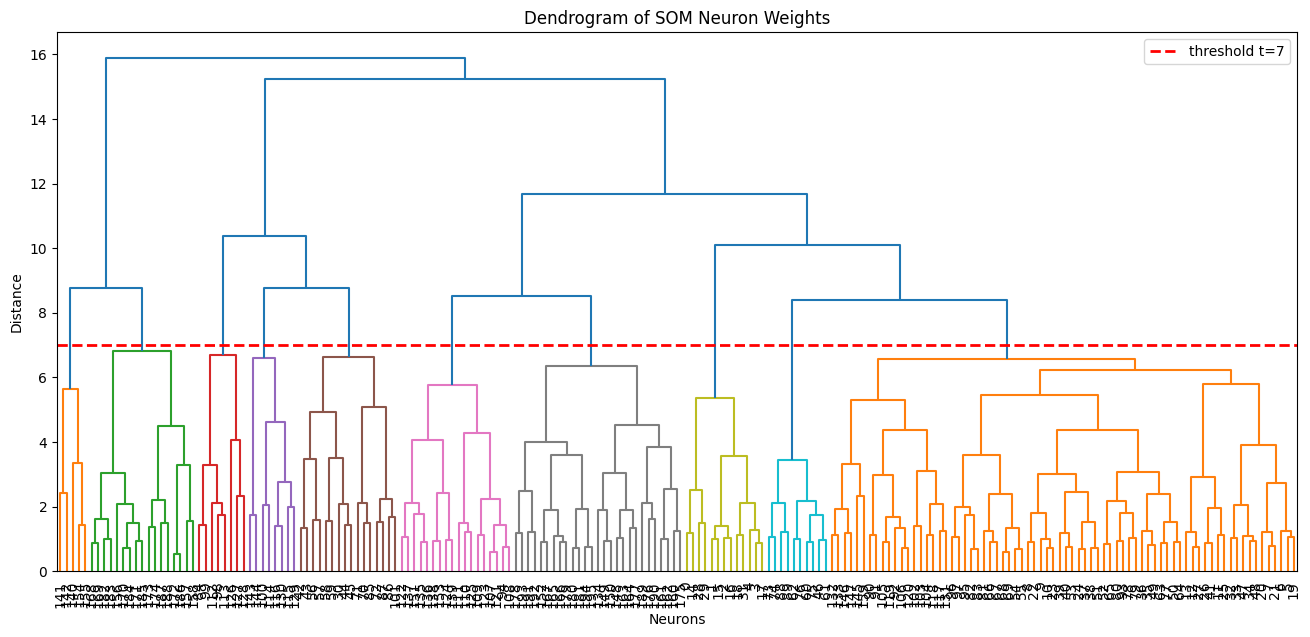

In [188]:
# ============================================================
# Compute the hierarchical clustering tree
# ============================================================
weights_2d = som.get_weights().reshape(-1, som.get_weights().shape[2])

Z = linkage(weights_2d, method='complete', metric='cityblock')

# ============================================================
# Visualize the dendrogram and try to identify the number of clusters of neurons
# ============================================================
t = 7  # threshold used for dendrogram coloring / cut visualization

fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(Z, color_threshold=t) # adjust threshold according to the number of cluster you want to obtain
ax.axhline(y=t, color='red', linestyle='--', linewidth=2, label=f"threshold t={t}")
ax.legend(loc='upper right')

ax.tick_params(axis='x', labelsize=10, labelrotation=90)   
ax.set_title('Dendrogram of SOM Neuron Weights')
ax.set_xlabel('Neurons')
ax.set_ylabel('Distance')
plt.show()


## 10) Define the Number of Clusters

Choose the number of clusters by cutting the dendrogram.

The variable `numCl` can be changed according to the desired partition.


In [189]:
# you may need to insert some codes above to define the number of cluster (compute the metrics and evaluate them)
# Automatically set numCl to the number of clusters induced by the dendrogram threshold t
clusterIdx = fcluster(Z, t, criterion='distance') - 1  # cluster labels starting from 0
numCl = int(np.unique(clusterIdx).size)

# 2D cluster map of the SOM neurons
cluster_map = clusterIdx.reshape(n, n)
print("Number of neuron clusters:", numCl)


Number of neuron clusters: 10



## 12) Identify Contiguous Neuron Bubbles

A bubble is defined as a group of neighboring neurons that:
- belong to the same neuron cluster  
- are contiguous on the SOM grid

Here we identify the connected components of the 2D cluster map using 4-neighborhood connectivity.
The function below helps you to visualize the bubble of neurons (i.e., groups of neighbour neurons). You can use this function to check if the groups are contigous or not.

The function create a figure with two subplots:
- On the lift side you can see the map of victories of the SOM. The number inside each neuron is the number of victories.
- On the righ side, you can see the neurons divided into N groups (N is the umber of clusters you defined before) with a colormap. The number inside is the cluster label.

You can also modify the function if you want to plot other information rather than the default ones.

In [190]:
# ============================================================
# Identify contiguous neuron bubbles via BFS (4-connectivity)
# ============================================================
def compute_bubbles(cluster_map):
    n_rows, n_cols = cluster_map.shape
    bubble_map = np.zeros((n_rows, n_cols), dtype=int)
    visited = np.zeros((n_rows, n_cols), dtype=bool)
    bubble_id = 0

    for i in range(n_rows):
        for j in range(n_cols):
            if not visited[i, j]:
                bubble_id += 1
                current_cluster = cluster_map[i, j]
                queue = deque([(i, j)])
                visited[i, j] = True

                while queue:
                    ci, cj = queue.popleft()
                    bubble_map[ci, cj] = bubble_id

                    for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                        ni, nj = ci + di, cj + dj
                        if (0 <= ni < n_rows and 0 <= nj < n_cols
                                and not visited[ni, nj]
                                and cluster_map[ni, nj] == current_cluster):
                            visited[ni, nj] = True
                            queue.append((ni, nj))

    return bubble_map

bubble_map = compute_bubbles(cluster_map)
print(f"Number of bubbles identified: {bubble_map.max()}")
print("Bubble map:")
print(bubble_map)


# ============================================================
# Visualization function: hits map + bubble map side by side
# ============================================================
def plot_som_hits_and_bubbles_side_by_side(
    som,
    hits,
    cluster_map,
    hex_radius=0.85 / np.sqrt(3),
    hits_cmap='Blues',
    bubbles_cmap='jet',
    hits_title='Hits Map',
    bubbles_title='Neuron Bubbles'
):

    # --------------------------------------------------------
    # 1. Extract SOM geometry
    # --------------------------------------------------------
    weights_3d = som.get_weights()
    n_rows, n_cols, _ = weights_3d.shape
    xx, yy = som.get_euclidean_coordinates()

    # --------------------------------------------------------
    # 2. Colormaps
    # --------------------------------------------------------
    hits_cmap_obj = cm.get_cmap(hits_cmap)
    max_hits = np.max(hits) if np.max(hits) > 0 else 1
    hits_norm = colors.Normalize(vmin=0, vmax=max_hits)

    num_clusters = int(np.max(cluster_map))
    bubbles_cmap_obj = cm.get_cmap(bubbles_cmap, num_clusters)

    # --------------------------------------------------------
    # 3. Create figure and axes
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    ax_hits, ax_bubbles = axes

    # --------------------------------------------------------
    # 4. Common axis formatting
    # --------------------------------------------------------
    def format_axis(ax):
        ax.set_aspect('equal')

        # Tick labels arranged for didactic reading:
        # left-to-right, top-to-bottom
        ax.set_xticks(np.arange(n_cols))
        ax.set_yticks(np.arange(n_rows) * np.sqrt(3) / 2)

        ax.set_xticklabels(np.arange(n_cols))
        ax.set_yticklabels(np.arange(n_rows - 1, -1, -1))

        yy_plot = yy * np.sqrt(3) / 2
        ax.set_xlim(xx.min() - 1, xx.max() + 1)
        ax.set_ylim(yy_plot.min() - 1, yy_plot.max() + 1)

    # --------------------------------------------------------
    # 5. Left subplot: hits map
    # --------------------------------------------------------
    for i in range(n_rows):
        for j in range(n_cols):
            # Visual arrangement:
            # row i is displayed from top to bottom
            # column j is displayed from left to right
            i_plot = n_rows - 1 - i
            j_plot = j

            wx = xx[(j_plot, i_plot)]
            wy = yy[(j_plot, i_plot)] * np.sqrt(3) / 2

            hit_value = hits[i, j]
            face_color = hits_cmap_obj(hits_norm(hit_value))

            hexagon = RegularPolygon(
                (wx, wy),
                numVertices=6,
                radius=hex_radius,
                facecolor=face_color,
                edgecolor='lightgray',
                linewidth=1.2
            )
            ax_hits.add_patch(hexagon)

            text_color = 'white' if hit_value > 0.6 * max_hits else 'black'
            ax_hits.text(
                wx, wy,
                str(hit_value),
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold',
                color=text_color
            )

    format_axis(ax_hits)
    ax_hits.set_title(hits_title, fontweight='bold')

    # --------------------------------------------------------
    # 6. Right subplot: bubble map
    # --------------------------------------------------------
    for i in range(n_rows):
        for j in range(n_cols):
            i_plot = n_rows - 1 - i
            j_plot = j

            wx = xx[(j_plot, i_plot)]
            wy = yy[(j_plot, i_plot)] * np.sqrt(3) / 2

            cluster_id = cluster_map[i, j]
            cluster_color = bubbles_cmap_obj(cluster_id - 1)

            hexagon = RegularPolygon(
                (wx, wy),
                numVertices=6,
                radius=hex_radius,
                facecolor=cluster_color,
                edgecolor=cluster_color,
                alpha=0.28,
                linewidth=2
            )
            ax_bubbles.add_patch(hexagon)

            ax_bubbles.text(
                wx, wy,
                str(cluster_id),
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold',
                color='black'
            )

    format_axis(ax_bubbles)
    ax_bubbles.set_title(bubbles_title, fontweight='bold')

    plt.tight_layout()
    plt.show()

Number of bubbles identified: 10
Bubble map:
[[ 1  1  1  1  1  2  2  2  2  2  2  2  2  2]
 [ 1  1  1  1  1  2  2  2  2  2  2  2  2  2]
 [ 1  1  3  1  2  2  2  2  2  2  2  2  2  2]
 [ 3  3  3  3  4  2  2  2  2  2  2  2  2  2]
 [ 3  3  3  3  4  4  4  2  2  2  2  2  2  2]
 [ 3  3  3  4  4  4  4  2  2  2  2  2  2  2]
 [ 5  3  3  3  4  4  2  2  2  2  6  2  2  2]
 [ 5  5  7  3  2  2  2  2  2  6  6  6  6  6]
 [ 5  5  7  7  7  2  2  2  2  6  6  6  6  6]
 [ 5  5  5  7  7  2  2  2  8  6  6  6  6  6]
 [ 9  9  9  7  7  2  2  2  8  8  8  6  8  6]
 [ 9  9 10 10 10  2  8  8  8  8  8  8  8  8]
 [10 10 10 10 10 10 10  8  8  8  8  8  8  8]
 [10 10 10 10 10 10 10  8  8  8  8  8  8  8]]


Here there's an example of how to use the function as it's written right now. If you change something in the function you may have to adjust also how you call it.

/var/folders/jy/2zl5klm95b9fcry_rjchybmm0000gn/T/ipykernel_30737/2202585066.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hits_cmap_obj = cm.get_cmap(hits_cmap)
/var/folders/jy/2zl5klm95b9fcry_rjchybmm0000gn/T/ipykernel_30737/2202585066.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bubbles_cmap_obj = cm.get_cmap(bubbles_cmap, num_clusters)


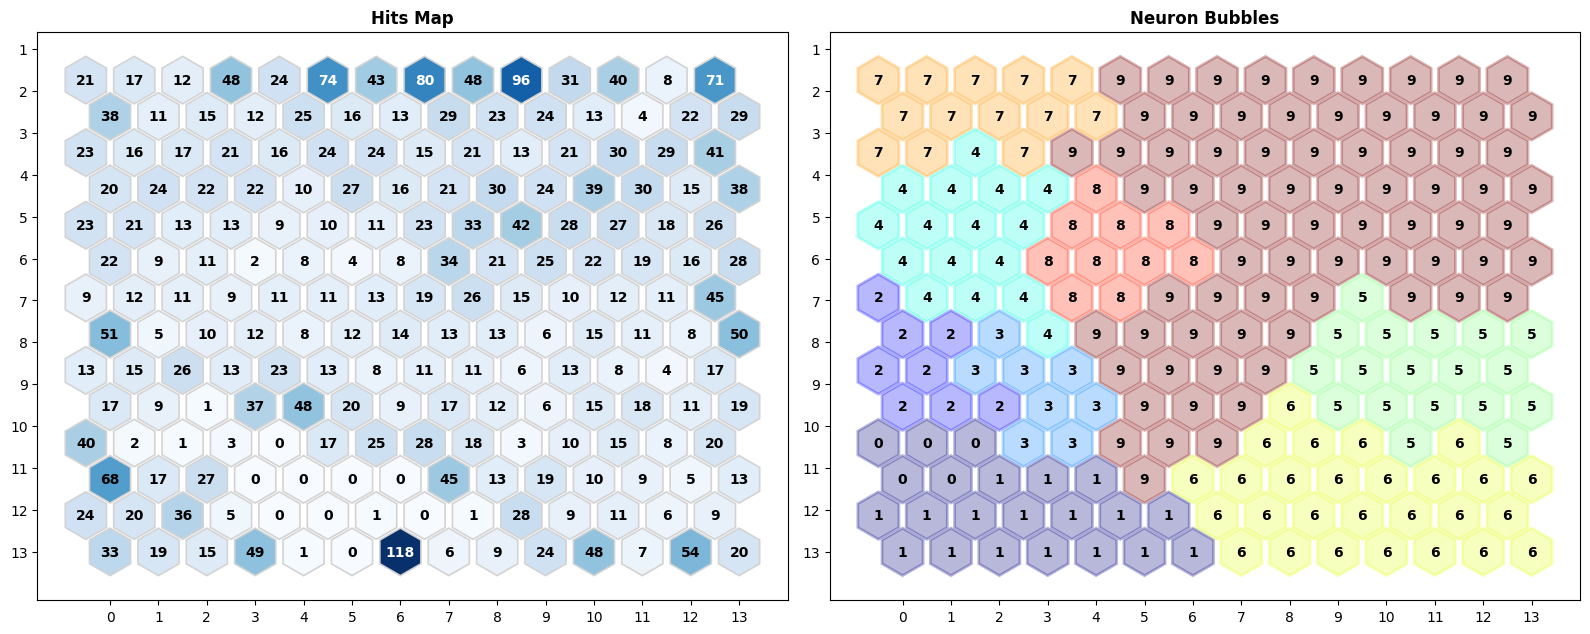

In [191]:
# Compute som hits (wins) 
hits = np.zeros((n, n), dtype=int)
for x in X_norm:
    i, j = som.winner(x)
    hits[i, j] += 1

# Plot som hits and bubbles
plot_som_hits_and_bubbles_side_by_side(
    som=som,
    hits=hits,
    cluster_map=cluster_map
)


## 14) Assign Subjects to Neurons, Clusters, and Bubbles

Each subject is assigned to:
- the winner neuron  
- the cluster of the winner neuron  
- the contiguous bubble containing the winner neuron


In [192]:
# ============================================================
# Assign each subject to winner neuron, cluster, and bubble
# ============================================================
id_cols = df.columns[:6].tolist()   # subject_id, hadm_id, stay_id, ICU, ICU_intime, ICU_outtime
outcome_col = 'outcome'

subject_winners  = []
subject_clusters = []
subject_bubbles  = []

for x in X_norm:
    winner = som.winner(x)                              # (row, col) of the winner neuron
    cluster_id = cluster_map[winner[0], winner[1]] + 1 # 1-indexed to match bubble_id convention
    bubble_id  = bubble_map[winner[0], winner[1]]       # already 1-indexed

    subject_winners.append(winner)
    subject_clusters.append(cluster_id)
    subject_bubbles.append(bubble_id)

subject_winners  = np.array(subject_winners)
subject_clusters = np.array(subject_clusters)
subject_bubbles  = np.array(subject_bubbles)

subjects_clustered = pd.concat([
    df[id_cols].reset_index(drop=True),
    pd.DataFrame({
        'winner_row': subject_winners[:, 0],
        'winner_col': subject_winners[:, 1],
        'cluster_id': subject_clusters,
        'bubble_id':  subject_bubbles,
    }),
    df[[outcome_col]].reset_index(drop=True),
], axis=1)

print(f"Subjects assigned: {len(subjects_clustered)}")
print(f"Clusters: {sorted(subjects_clustered['cluster_id'].unique())}")
print(f"Bubbles:  {sorted(subjects_clustered['bubble_id'].unique())}")
subjects_clustered.head()

Subjects assigned: 3893
Clusters: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10)]
Bubbles:  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,winner_row,winner_col,cluster_id,bubble_id,outcome
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,0,11,10,2,2
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,9,3,4,7,1
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,8,2,4,7,1
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,9,13,6,6,2
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,7,0,3,5,2



## 15) Explore the Subjects in Each Cluster

The following cell prints the number of subjects assigned to each cluster and each bubble. Modify it if you want to analyze something more.


In [193]:

print("Subjects per cluster:")
cluster_summary = (
    subjects_clustered
    .groupby('cluster_id')
    .size()
    .reset_index(name='n_subjects')
    .sort_values(by='cluster_id')
)

cluster_summary

Subjects per cluster:


,cluster_id,n_subjects
0,1,128
1,2,348
2,3,120
3,4,160
4,5,261
5,6,252
6,7,397
7,8,283
8,9,84
9,10,1860



## 16) Save the Final Results

Save the subject assignments as a file (.csv or .xlsx or whatever you prefer).

You can also save one file per cluster if you prefer. Remember to restore the information about the IDs (first 6 columns) and the outcome (last column) of the initial dataset.


In [194]:

results_filename = "subject_assignments.xlsx"
subjects_clustered.to_excel(results_filename, index=False)
print("Saved subject assignments to:", results_filename)


Saved subject assignments to: subject_assignments.xlsx
